# Importing Libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Loading Dataset

In [36]:
df = pd.read_csv('D:\student\student-mat.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Inspect data types

In [23]:
print("--- Data Info ---")
df.info()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    obje

# Descriptive statistics for numerical columns

In [24]:
print("\n--- Statistical Summary ---")
df.describe()


--- Statistical Summary ---


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# Check for null values

In [25]:
missing_count = df.isnull().sum().sum()
print(f"Total missing values: {missing_count}")

Total missing values: 0


# Check for duplicate rows

In [26]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Total duplicate rows found: 0


# Average Final Grade (G3) with Histogram

In [27]:
average_g3 = df['G3'].mean()
print(f"The average final grade (G3) is: {average_g3:.2f}")

The average final grade (G3) is: 10.42


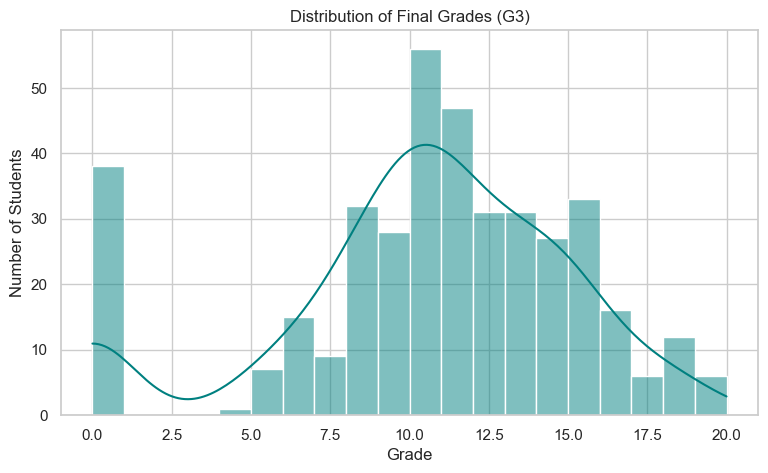

In [30]:
plt.figure(figsize=(9, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='teal')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()

# Students scoring above 15

In [28]:
above_marks = df[df['G3'] > 15]
print(f"Number of students who scored above 15: {len(above_marks)}")

Number of students who scored above 15: 40


# Study time Vs Performance correlation with Scatterplot

In [29]:
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between Study Time and Final Grade: {correlation:.2f}")

Correlation between Study Time and Final Grade: 0.10


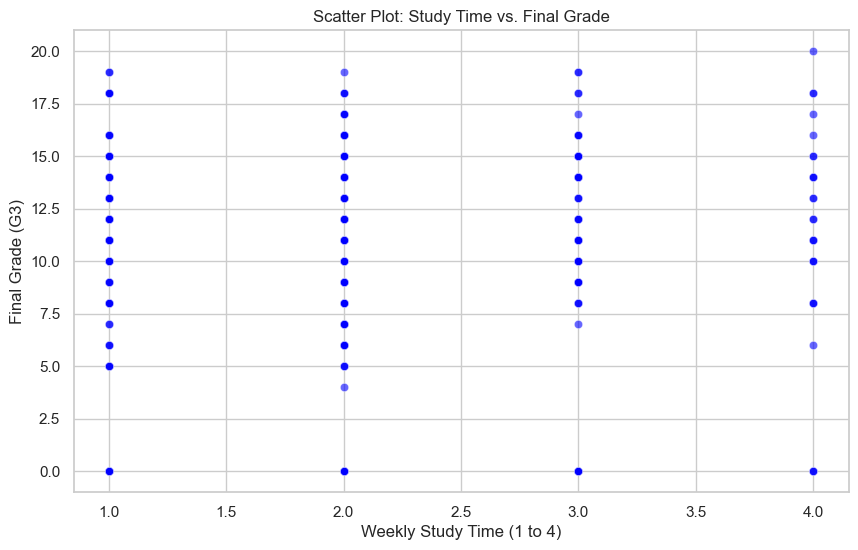

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='studytime', y='G3', data=df, alpha=0.6, color='blue')
plt.title('Scatter Plot: Study Time vs. Final Grade')
plt.xlabel('Weekly Study Time (1 to 4)')
plt.ylabel('Final Grade (G3)')
plt.show()

# Mean final grade by Gender with bar chart

In [32]:
gender_avg = df.groupby('sex')['G3'].mean()
print("Average Final Grade (G3) by Gender:")
print(f"Female (F): {gender_avg['F']:.2f}")
print(f"Male (M):   {gender_avg['M']:.2f}")

Average Final Grade (G3) by Gender:
Female (F): 9.97
Male (M):   10.91


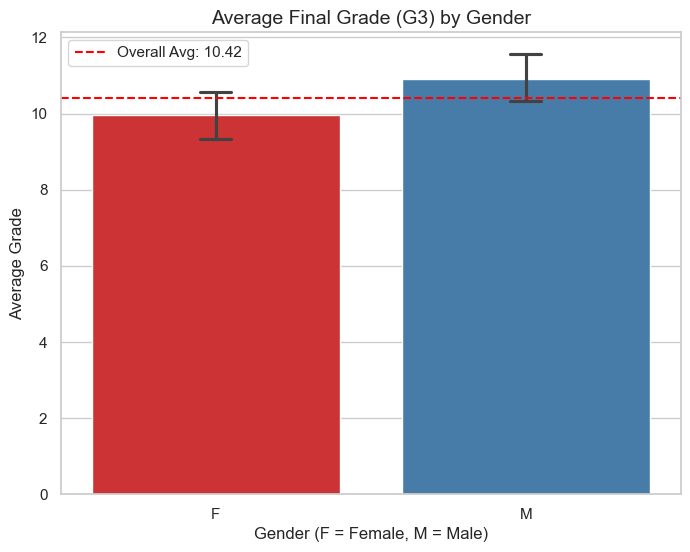

In [35]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='G3', data=df, palette='Set1', capsize=.1)
plt.title('Average Final Grade (G3) by Gender', fontsize=14)
plt.xlabel('Gender (F = Female, M = Male)', fontsize=12)
plt.ylabel('Average Grade', fontsize=12)
plt.axhline(df['G3'].mean(), color='red', linestyle='--', label=f"Overall Avg: {df['G3'].mean():.2f}")
plt.legend()
plt.show()